In [30]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import itertools

# sns.set_theme(style="whitegrid")
sns.set_palette("magma")


df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/course/datasets/df_full_last_version_1.csv')
df = df.dropna()
columns_ex = ['close', 'high', 'low', 'timestamp', 'open']

df_cl = df.drop(columns=columns_ex)

train_size = int(len(df_cl) * 0.8)
df_train = df_cl.iloc[:train_size].copy()
window = 12
df_test = df_cl.iloc[train_size + window:].copy()

In [35]:
import itertools
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
from tqdm.auto import tqdm

# Список столбцов, которые мы хотим перебрать (кандидаты на вылет/оставление)
sentiment_cols = ['sentiment_1h', 'sentiment_4h', 'sentiment_12h', 'sentiment_24h', 'sentiment_168h']

# Базовые колонки, которые удаляем ВСЕГДА (цены и время)
always_drop = ['close', 'high', 'low', 'open', 'timestamp', 'target']

# Подготовка базовых данных (X и y)
# df_train и df_test у тебя уже должны быть загружены из предыдущих ячеек
X_train_full = df_train.copy()
y_train = df_train['target']
X_test_full = df_test.copy()
y_test = df_test['target']

results = []

print(f"Начинаем перебор всех комбинаций из {len(sentiment_cols)} столбцов сентимента...")

# Перебираем все возможные длины комбинаций (от 0 до всех 5)
# r - это сколько столбцов сентимента мы ОСТАВЛЯЕМ
for r in tqdm(range(len(sentiment_cols) + 1)):
    # Генерируем сочетания
    combinations = itertools.combinations(sentiment_cols, r)

    for keep_cols in combinations:
        # 1. Определяем текущий набор признаков
        # Сначала берем всё, что нужно выкинуть по умолчанию
        drop_cols = list(always_drop)

        # Теперь добавляем в список "на выброс" те сентименты,
        # которых НЕТ в текущем наборе keep_cols
        for col in sentiment_cols:
            if col not in keep_cols:
                drop_cols.append(col)

        # 2. Формируем X_train и X_test для текущей итерации
        # (Проверяем, чтобы не пытаться удалить то, чего нет)
        current_drop = [c for c in drop_cols if c in X_train_full.columns]

        X_train_curr = X_train_full.drop(columns=current_drop)
        X_test_curr = X_test_full.drop(columns=current_drop)

        # 3. Обучаем модель (быстро, меньше деревьев для скорости перебора)
        model = RandomForestClassifier(n_estimators=50, min_samples_leaf=5, n_jobs=-1, random_state=42)
        model.fit(X_train_curr, y_train)

        # 4. Предсказываем
        y_probs = model.predict_proba(X_test_curr)

        # Упрощенная логика оценки (симуляция твоего threshold)
        threshold = 0.52
        y_pred_custom = []

        for probs in y_probs:
            idx = np.argmax(probs)
            # Классы модели: 0->-1, 1->0, 2->1 (обычно так, но лучше проверить model.classes_)
            # Предполагаем стандарт: classes_ = [-1, 0, 1]
            predicted_class = model.classes_[idx]
            confidence = probs[idx]

            if confidence > threshold and predicted_class != 0:
                y_pred_custom.append(predicted_class)
            else:
                y_pred_custom.append(0) # 0 как "нет сделки"

        # 5. Считаем метрику (Precision для классов -1 и 1)
        # Нам важно, чтобы когда модель говорит "ВХОДИ", она не врала.
        # labels=[-1, 1] значит игнорируем класс 0 (флэт) при расчете
        score = precision_score(y_test, y_pred_custom, labels=[-1, 1], average='weighted', zero_division=0)

        # Считаем кол-во сигналов (чтобы не выбрать модель, которая молчит)
        n_trades = np.sum(np.array(y_pred_custom) != 0)

        # Сохраняем результат
        results.append({
            'cols': keep_cols,
            'score': score,
            'trades': n_trades
        })

# вывод
# Сортируем по Score (качеству) и берем топ
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='score', ascending=False)

print("\n=== ТОП-3 ЛУЧШИХ КОМБИНАЦИИ СЕНТИМЕНТА ===")
for i in range(min(3, len(results_df))):
    row = results_df.iloc[i]
    cols_str = ", ".join(row['cols']) if row['cols'] else "БЕЗ СЕНТИМЕНТА"
    print(f"{i+1}. Столбцы: [{cols_str}]")
    print(f"   Precision (weighted): {row['score']:.4f} | Сделок: {row['trades']}")
    print("-" * 40)

Начинаем перебор всех комбинаций из 5 столбцов сентимента...


  0%|          | 0/6 [00:00<?, ?it/s]


=== ТОП-3 ЛУЧШИХ КОМБИНАЦИИ СЕНТИМЕНТА ===
1. Столбцы: [sentiment_4h, sentiment_12h, sentiment_168h]
   Precision (weighted): 0.6988 | Сделок: 22
----------------------------------------
2. Столбцы: [БЕЗ СЕНТИМЕНТА]
   Precision (weighted): 0.6145 | Сделок: 21
----------------------------------------
3. Столбцы: [sentiment_1h, sentiment_4h, sentiment_12h, sentiment_24h, sentiment_168h]
   Precision (weighted): 0.6133 | Сделок: 22
----------------------------------------


Победившая комбинация [4h, 12h, 168h] очень логична:

168h (Неделя) дает глобальный фон (бычий или медвежий рынок).

12h и 4h дают среднесрочный тренд.

А вот 1h (шум) и 24h (суточный лаг) оказались лишними.

In [37]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
from tqdm.auto import tqdm

# 1. ФИКСИРУЕМ ЛУЧШИЕ ПРИЗНАКИ (из твоего результата)
best_sentiment_cols = ['sentiment_4h', 'sentiment_12h', 'sentiment_168h']

# Список всех возможных сентиментов, которые были в датасете
all_possible_sentiments = ['sentiment_1h', 'sentiment_4h', 'sentiment_12h', 'sentiment_24h', 'sentiment_168h']

# Вычисляем, какие сентименты нужно УДАЛИТЬ (те, что не вошли в топ)
sentiment_to_drop = [col for col in all_possible_sentiments if col not in best_sentiment_cols]

# Базовые колонки на удаление (цены + время + таргет + плохие сентименты)
# ВАЖНО: 'open' удаляем обязательно!
cols_to_drop = ['close', 'high', 'low', 'open', 'timestamp', 'target'] + sentiment_to_drop

# 2. ГОТОВИМ ДАННЫЕ ОДИН РАЗ
# Проверяем, какие колонки есть в df_train перед удалением, чтобы не было ошибки
actual_drop = [c for c in cols_to_drop if c in df_train.columns]

X_train_final = df_train.drop(columns=actual_drop)
y_train = df_train['target']

X_test_final = df_test.drop(columns=actual_drop)
y_test = df_test['target']

print(f"Обучаемся на признаках: {list(X_train_final.columns)}")

# 3. СЕТКА ПАРАМЕТРОВ
n_estimators_list = [50, 100, 200, 300, 500]
max_depth_list = [3, 5, 7, 10, 15, None] # None = без ограничений

results = []
print(f"\nНачинаем подбор гиперпараметров...")

# Запускаем перебор
for n_est in tqdm(n_estimators_list, desc="Trees"):
    for depth in max_depth_list:

        # Обучение
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            min_samples_leaf=5, # Оставляем 5 как защиту от шума
            n_jobs=-1,
            random_state=42
        )
        model.fit(X_train_final, y_train)

        # Предсказание
        y_probs = model.predict_proba(X_test_final)

        # Оценка (симуляция торговли с порогом 0.52)
        threshold = 0.52
        y_pred_custom = []

        for probs in y_probs:
            idx = np.argmax(probs)
            predicted_class = model.classes_[idx]
            confidence = probs[idx]

            if confidence > threshold and predicted_class != 0:
                y_pred_custom.append(predicted_class)
            else:
                y_pred_custom.append(0)

        # Считаем Precision (взвешенный для классов -1 и 1)
        score = precision_score(y_test, y_pred_custom, labels=[-1, 1], average='weighted', zero_division=0)
        n_trades = np.sum(np.array(y_pred_custom) != 0)

        results.append({
            'n_estimators': n_est,
            'max_depth': depth,
            'score': score,
            'trades': n_trades
        })

# 4. ВЫВОД РЕЗУЛЬТАТОВ
res_df = pd.DataFrame(results)
# Сортируем: сначала по Score, потом по кол-ву сделок
res_df = res_df.sort_values(by=['score', 'trades'], ascending=False)

print("\n=== ТОП-5 ЛУЧШИХ НАСТРОЕК ===")
print(res_df.head(5).to_string(index=False))

# Сохраняем лучшую модель в переменную, чтобы ты мог её сразу использовать
best_params = res_df.iloc[0]
print(f"\nПобедитель: Trees={best_params['n_estimators']}, Depth={best_params['max_depth']}")

Обучаемся на признаках: ['volume', 'open_prev_1_pct', 'high_prev_1_pct', 'low_prev_1_pct', 'close_prev_1_pct', 'volume_prev_1_pct', 'open_prev_4_pct', 'high_prev_4_pct', 'low_prev_4_pct', 'close_prev_4_pct', 'volume_prev_4_pct', 'open_prev_12_pct', 'high_prev_12_pct', 'low_prev_12_pct', 'close_prev_12_pct', 'volume_prev_12_pct', 'open_prev_24_pct', 'high_prev_24_pct', 'low_prev_24_pct', 'close_prev_24_pct', 'volume_prev_24_pct', 'open_prev_168_pct', 'high_prev_168_pct', 'low_prev_168_pct', 'close_prev_168_pct', 'volume_prev_168_pct', 'sentiment_4h', 'sentiment_12h', 'sentiment_168h', 'ATR', 'RSI']

Начинаем подбор гиперпараметров...


Trees:   0%|          | 0/5 [00:00<?, ?it/s]


=== ТОП-5 ЛУЧШИХ НАСТРОЕК ===
 n_estimators  max_depth    score  trades
           50        NaN 0.698783      22
          200       10.0 0.349138       4
          300       10.0 0.349138       4
           50       10.0 0.232759       6
          100       10.0 0.232759       6

Победитель: Trees=50.0, Depth=nan


In [50]:
model = RandomForestClassifier(n_estimators=50, n_jobs=-1, min_samples_leaf=5, random_state=42)
model.fit(X_train_final, y_train)

y_probs = model.predict_proba(X_test_final)

y_final_pred = []
threshold = 0.52

for lst in y_probs:

    indx = np.argmax(lst)
    # не берем в учет флэт
    if lst[indx] > threshold and indx != 1:
        y_final_pred.append(indx - 1)
    else:
        y_final_pred.append(2)

y_final_pred = np.array(y_final_pred)

# Фильтруем и считаем метрики
mask = y_final_pred != 2
if mask.sum() > 0:
    acc = accuracy_score(y_test[mask], y_final_pred[mask])
    print(f"\n=== РЕЗУЛЬТАТЫ СТРАТЕГИИ (Порог {threshold}) ===")
    print(f"Совершено сделок: {mask.sum()} из {len(y_test)} (Coverage: {mask.sum()/len(y_test)*100:.2f}%)")
    print(f"Точность (Win Rate): {acc:.4f}")
    print("\n", classification_report(y_test[mask], y_final_pred[mask]))
else:
    print("Модель не сделала ни одной ставки. Снизь порог уверенности.")


=== РЕЗУЛЬТАТЫ СТРАТЕГИИ (Порог 0.52) ===
Совершено сделок: 22 из 3732 (Coverage: 0.59%)
Точность (Win Rate): 0.5000

               precision    recall  f1-score   support

        -1.0       1.00      0.45      0.62        11
         0.0       0.00      0.00      0.00         5
         1.0       0.35      1.00      0.52         6

    accuracy                           0.50        22
   macro avg       0.45      0.48      0.38        22
weighted avg       0.60      0.50      0.45        22



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


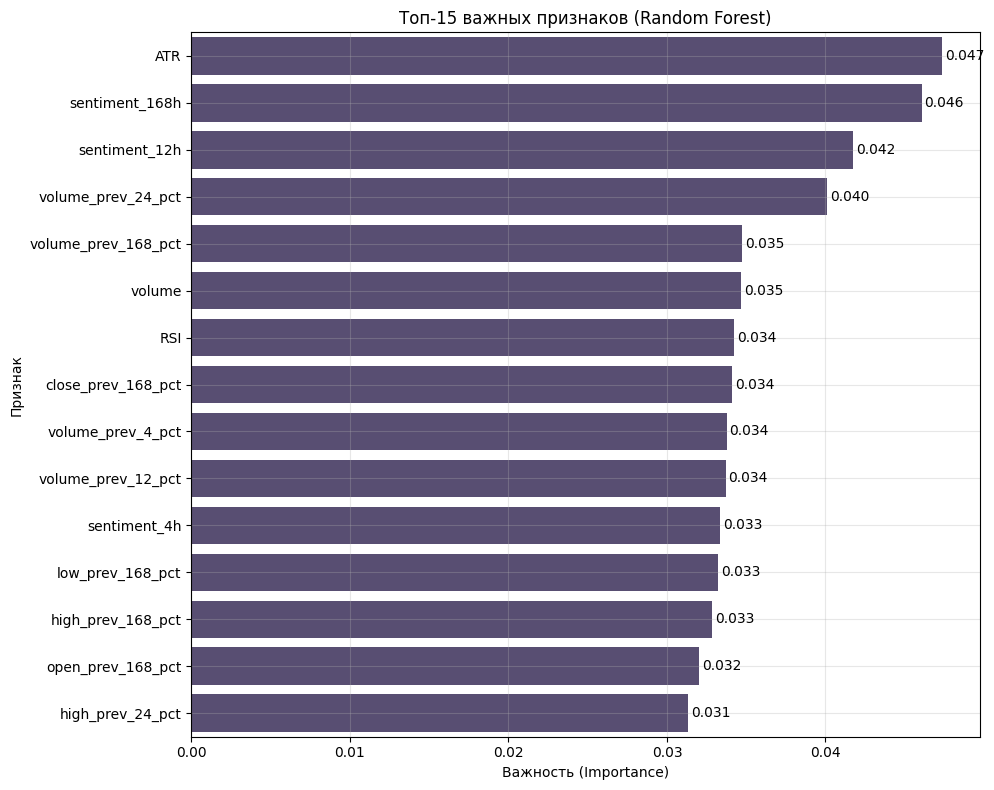

                Feature  Importance
29                  ATR    0.047381
28       sentiment_168h    0.046063
27        sentiment_12h    0.041750
20   volume_prev_24_pct    0.040118
25  volume_prev_168_pct    0.034746
0                volume    0.034702
30                  RSI    0.034245
24   close_prev_168_pct    0.034104
10    volume_prev_4_pct    0.033760
15   volume_prev_12_pct    0.033713
26         sentiment_4h    0.033363
23     low_prev_168_pct    0.033214
22    high_prev_168_pct    0.032868
21    open_prev_168_pct    0.032016
17     high_prev_24_pct    0.031344


In [42]:
# Feature Importance
show_fetures = 15

importances = model.feature_importances_
feature_names = X_train_final.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(show_fetures), alpha=0.77)
plt.title('Топ-15 важных признаков (Random Forest)')
plt.xlabel('Важность (Importance)')
plt.ylabel('Признак')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')

# Fix: Use ax.containers to get the bar container from the barplot
for container in ax.containers:
    plt.bar_label(container, padding=2, fmt='%.3f')

plt.grid(alpha=0.3)
plt.show()

print(feature_importance_df.head(show_fetures))

Запуск симуляции (Threshold: 0.52)...


100%|██████████| 3719/3719 [00:00<00:00, 49940.82it/s]



Финальный депозит: 1072.14$
Всего сделок: 22
Win Rate: 50.00%


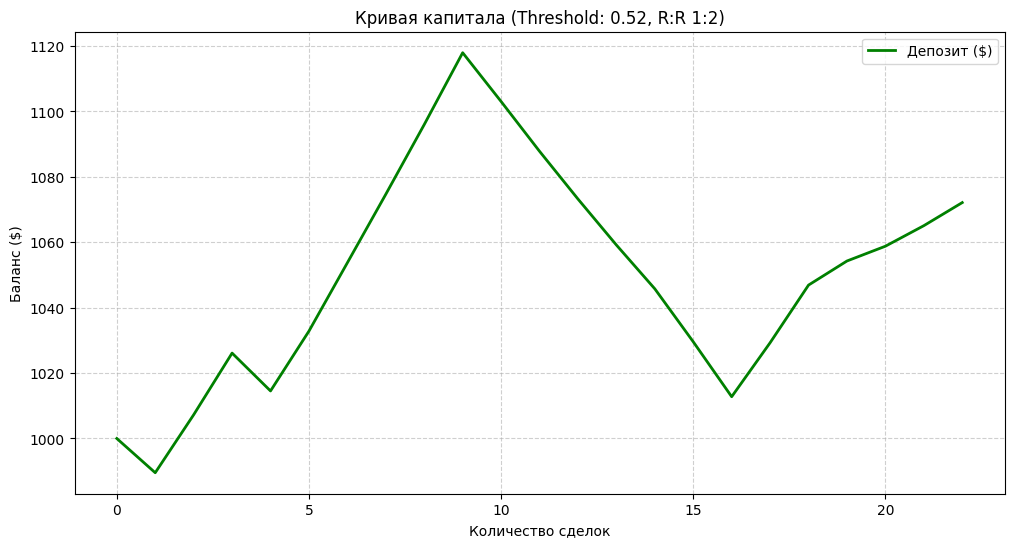

In [52]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# === НАСТРОЙКИ ===
threshold = 0.52  # Твой порог уверенности
equity = 1000     # Стартовый капитал
commission = 0.0006 # 0.06%
look_ahead = 12   # Горизонт прогноза

# Сюда будем сохранять историю изменения баланса для графика
equity_history = [equity]
history = []

# Берем индексы из теста
test_indices = df_test.index

print(f"Запуск симуляции (Threshold: {threshold})...")

# 1. Предсказания делаем ОДИН раз до цикла
all_probs = model.predict_proba(X_test_final)

for i in tqdm(range(len(test_indices) - look_ahead - 1)):
    idx = test_indices[i]

    # Берем вероятности
    probs = all_probs[i]

    # Логика классов: индекс 0 -> -1 (Short), индекс 2 -> 1 (Long)
    predicted_idx = np.argmax(probs)
    confidence = probs[predicted_idx]

    prediction = 0
    if predicted_idx == 0:
        prediction = -1
    elif predicted_idx == 2:
        prediction = 1

    # Фильтр
    if confidence < threshold or prediction == 0:
        continue

    # 2. Данные для сделки
    entry_price = df.loc[idx, 'close']
    atr = df.loc[idx, 'ATR']

    # Risk/Reward 1:2
    tp_dist = 2 * atr
    sl_dist = atr

    tp_price = entry_price + tp_dist if prediction == 1 else entry_price - tp_dist
    sl_price = entry_price - sl_dist if prediction == 1 else entry_price + sl_dist

    # 3. Проход в будущее
    outcome = 0
    for future_i in range(1, look_ahead + 1):
        future_idx = test_indices[i + future_i]
        curr_high = df.loc[future_idx, 'high']
        curr_low = df.loc[future_idx, 'low']

        if prediction == 1: # ЛОНГ
            if curr_low <= sl_price:
                outcome = -1
                break
            if curr_high >= tp_price:
                outcome = 1
                break
        elif prediction == -1: # ШОРТ
            if curr_high >= sl_price:
                outcome = -1
                break
            if curr_low <= tp_price:
                outcome = 1
                break

    # 4. Расчет PnL и обновление графика
    pnl = 0
    if outcome == 1:
        pnl = (abs(tp_price - entry_price) / entry_price) - (2 * commission)
        equity *= (1 + pnl)
        history.append('WIN')
    elif outcome == -1:
        pnl = (abs(entry_price - sl_price) / entry_price) + (2 * commission)
        equity *= (1 - pnl) # Вычитаем убыток
        history.append('LOSS')
    else:
        # Time Exit
        exit_idx = test_indices[i + look_ahead]
        close_price = df.loc[exit_idx, 'close']
        raw_pnl = (close_price - entry_price) / entry_price
        if prediction == -1: raw_pnl = -raw_pnl

        pnl = raw_pnl - (2 * commission)
        equity *= (1 + pnl)
        history.append('TIME_EXIT')

    equity_history.append(equity)

print(f"\nФинальный депозит: {equity:.2f}$")
print(f"Всего сделок: {len(history)}")
if len(history) > 0:
    win_rate = history.count('WIN') / len(history) * 100
    print(f"Win Rate: {win_rate:.2f}%")
else:
    print("Нет сделок")

plt.figure(figsize=(12, 6))
plt.plot(equity_history, label='Депозит ($)', color='green', linewidth=2)
plt.title(f'Кривая капитала (Threshold: {threshold}, R:R 1:2)')
plt.xlabel('Количество сделок')
plt.ylabel('Баланс ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [53]:
from google.colab import files

# 1. Создаем простую таблицу
# equity_history - это список, который мы заполнили в прошлом шаге
df_export = pd.DataFrame({
    'Trade': range(len(equity_history)), # Номер сделки (0, 1, 2...)
    'Balance': equity_history            # Твой депозит
})

# 2. Сохраняем в файл CSV (без индекса, чтобы Canva не запуталась)
filename = 'my_strategy_results.csv'
df_export.to_csv(filename, index=False)

print(f"Файл {filename} создан. Скачивание начнется автоматически...")

# 3. Скачиваем файл на твой компьютер
files.download(filename)

Файл my_strategy_results.csv создан. Скачивание начнется автоматически...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# 1. Достаем данные из модели
# model - это твой обученный Random Forest
# X_train - это таблица, на которой он учился (нужна для названий колонок)
importances = model.feature_importances_
feature_names = X_train_final.columns

# 2. Создаем красивую табличку
df_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

df_features_sorted = df_features.sort_values(by='Importance', ascending=False).head(7)

# 4. Сохраняем в CSV для Canva
filename_features = 'feature_importance_top15.csv'
df_features_sorted.to_csv(filename_features, index=False)

# 5. Скачиваем
files.download(filename_features)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>